# OpenVLA Experiment

В статье OpenVLA действия робота превращаются в токены (tokenized actions).
Это удобно для:
 - LLM
 - autoregressive generation
 - масштабирования.

Но появляется проблема - discretization error.

Когда непрерывные действия:
a=0.137


заменяются токеном:
a≈0.1

теряется точность управления.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Создаем действия робота

In [2]:
actions = np.random.normal(0, 0.3, 5000)
actions = np.clip(actions, -1, 1)

## Используем  квантизацию
Т.е. каждому действию сопоставляем центр соответствующего интервала

In [3]:
def uniform_quantization(x, bins):

    edges = np.linspace(-1, 1, bins + 1)

    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, bins - 1)

    centers = (edges[:-1] + edges[1:]) / 2

    return centers[idx]


## Адаптивная квантизация
То же самое, только теперь интервалы не одинаковые

In [4]:
def adaptive_quantization(x):

    edges = np.array([
        -1.0, -0.6, -0.3, -0.15,
        -0.05, 0.05,
        0.15, 0.3, 0.6, 1.0
    ])

    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, len(edges)-2)

    centers = (edges[:-1] + edges[1:]) / 2

    return centers[idx]


## Смотрим на MSE двух функций


In [5]:
uniform_recon = uniform_quantization(actions, 8)
adaptive_recon = adaptive_quantization(actions)

uniform_mse = np.mean((actions - uniform_recon) ** 2)
adaptive_mse = np.mean((actions - adaptive_recon) ** 2)

print("Uniform MSE:", uniform_mse)
print("Adaptive MSE:", adaptive_mse)


Uniform MSE: 0.005231914484322318
Adaptive MSE: 0.003800150362498782


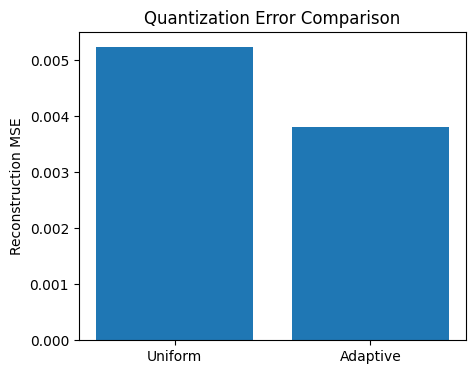

In [6]:
methods = ["Uniform", "Adaptive"]
errors = [uniform_mse, adaptive_mse]

plt.figure(figsize=(5,4))

plt.bar(methods, errors)

plt.ylabel("Reconstruction MSE")
plt.title("Quantization Error Comparison")

plt.show()


## Вывод:
Полученные результаты показывают, что adaptive discretization позволяет более точно представлять непрерывные управляющие сигналы без увеличения размера action vocabulary. Это может повысить качество low-level управления и уменьшить потери, связанные с квантованием действий в VLA-моделях.
